# Application: GWAS Analysis

This tutorial demonstrates how STARNet-inferred gene regulatory networks (GRNs) can be integrated with spatial GWAS enrichment results. The workflow follows the Fig5 analysis pattern on the human hippocampus dataset: annotate spatial domains, summarize trait enrichment across domains, inspect GRN enrichment in the CA3-4/GCL region, map a schizophrenia GWAS signal onto space, connect significant SNPs to TF-target regulatory relationships, and inspect the NCAM1 regulatory locus.

The notebook uses files already available in `Drive`. Download the tutorial data from [Links to Data Folder](https://drive.google.com/drive/folders/1obqewcAAvcUi8WOhqomKDo7BO_GncNvP?usp=sharing). The STARNet processed AnnData object, gsMap-derived spot-level p-values, Cauchy domain-level results, GWAS summary statistics, and precomputed ATAC tracks are loaded from the same tutorial data folder. Peak-to-gene links are also recalculated from the STARNet AnnData object to show the pipeline step used before genome-track visualization.

This tutorial uses STARNet for GRN and GWAS integration, gsMap-derived spatial trait p-values for spatial enrichment, Scanpy for AnnData handling and spatial plotting, NetworkX through STARNet for the GRN network visualization, and Logomaker for motif visualization. Full citations are listed at the end of the notebook.

## Setup

Import the required packages, define the paths used throughout the tutorial, and keep plotting options compact. The helper function rotates spatial coordinates to match the orientation used in the Fig5 reference plots.


In [9]:
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import STARNet as ST

DATA_DIR = "Drive/Datasets/Human_Hippocampus/Process_Data"
REF_DIR = "Drive/Datasets/Reference/human_v42"
GTF_PATH = f"{REF_DIR}/gencode.v42.annotation.gtf"
MOTIF_PATH = f"{REF_DIR}/cisBP_human.meme"
SCZ_GWAS_PATH = f"{DATA_DIR}/PGC3_SCZ_wave3_public_INFO80.txt"

DOMAIN_ORDER = ["GCL", "CA3-4", "CA_Other", "ML", "CP"]
DOMAIN_COLORS = {
    "GCL": "#81C0DD",
    "CA3-4": "#3E8CB1",
    "CA_Other": "#6BBBA0",
    "ML": "#5860A7",
    "CP": "#B2B0D4",
}

sc.settings.set_figure_params(dpi=120, vector_friendly=True)
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


def rotate_points_90_degrees_counterclockwise(points):
    return np.array([-points[:, 1], points[:, 0]]).T


## Load Data and Annotate Spatial Domains

We load the STARNet-processed human hippocampus AnnData object from `Drive`. The tutorial uses `tmp_fig4_rna.h5ad` because it contains the ten Leiden clusters and regulatory peak links used by the Fig5 GWAS analysis. We also attach the provided GRN `-log10(P)` score matrix so the GRN-level Cauchy combination test can be reproduced from existing Drive files.

The Leiden clusters are mapped to hippocampal domains using the Fig5 annotation scheme. We also define a merged `CA3-4 & GCL` domain for the GRN-level Cauchy combination test, following the reference analysis.

[<Axes: title={'center': 'spatial domain'}, xlabel='spatial1', ylabel='spatial2'>,
 <Axes: title={'center': 'spatial domain ID'}, xlabel='spatial1', ylabel='spatial2'>]

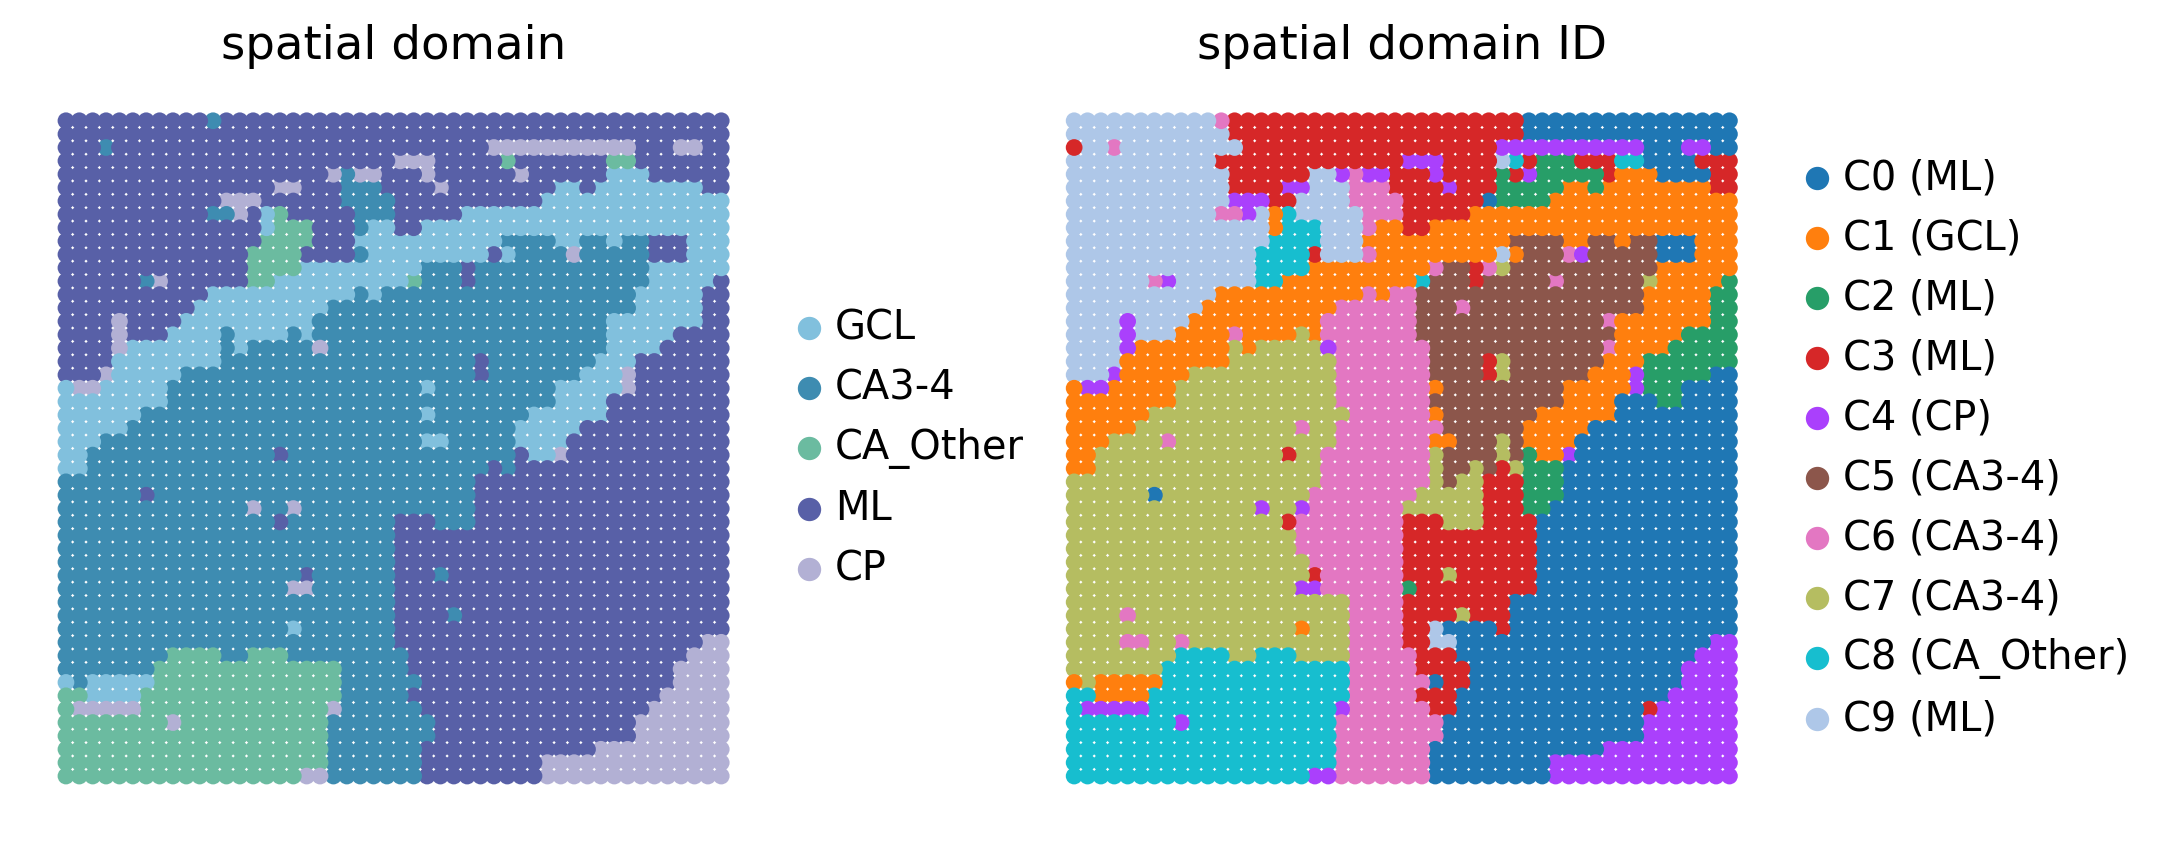

In [10]:
adata_rna = sc.read_h5ad(f"{DATA_DIR}/adata_rna_GRN.h5ad")
adata_rna.obsm["spatial"] = rotate_points_90_degrees_counterclockwise(adata_rna.obsm["spatial"])

cluster2annotation_id = {
    "0": "C0 (ML)",
    "1": "C1 (GCL)",
    "2": "C2 (ML)",
    "3": "C3 (ML)",
    "4": "C4 (CP)",
    "5": "C5 (CA3-4)",
    "6": "C6 (CA3-4)",
    "7": "C7 (CA3-4)",
    "8": "C8 (CA_Other)",
    "9": "C9 (ML)",
}
cluster2annotation = {
    "0": "ML",
    "1": "GCL",
    "2": "ML",
    "3": "ML",
    "4": "CP",
    "5": "CA3-4",
    "6": "CA3-4",
    "7": "CA3-4",
    "8": "CA_Other",
    "9": "ML",
}
cluster2annotation_merged = {
    "0": "ML",
    "1": "CA3-4 & GCL",
    "2": "ML",
    "3": "ML",
    "4": "CP",
    "5": "CA3-4 & GCL",
    "6": "CA3-4 & GCL",
    "7": "CA3-4 & GCL",
    "8": "CA_Other",
    "9": "ML",
}

leiden = adata_rna.obs["leiden"].astype(str)
adata_rna.obs["spatial domain ID"] = leiden.map(cluster2annotation_id).astype("category")
adata_rna.obs["spatial domain"] = pd.Categorical(leiden.map(cluster2annotation), categories=DOMAIN_ORDER)
adata_rna.obs["spatial domain new"] = pd.Categorical(leiden.map(cluster2annotation_merged))
adata_rna.uns["spatial domain_colors"] = [DOMAIN_COLORS[domain] for domain in DOMAIN_ORDER]

sc.pl.spatial(
    adata_rna,
    color=["spatial domain", 'spatial domain ID'],
    spot_size=1.25,
    legend_fontsize=12,
    show=False,
    frameon=False,
)


## Trait Enrichment Across Spatial Domains

The file `Cauchy_result.csv` contains domain-level Cauchy combination results derived from gsMap spot-level p-values. Each value is a `-log10(P)` score, so larger values indicate stronger enrichment of a trait in a spatial domain.

Here we reproduce the complete Fig5 trait-enrichment heatmap: traits are filtered by the Fig5 `-log10(P) > 5` cutoff, renamed for readability, ordered as in Fig5, and sorted by the GCL enrichment score.


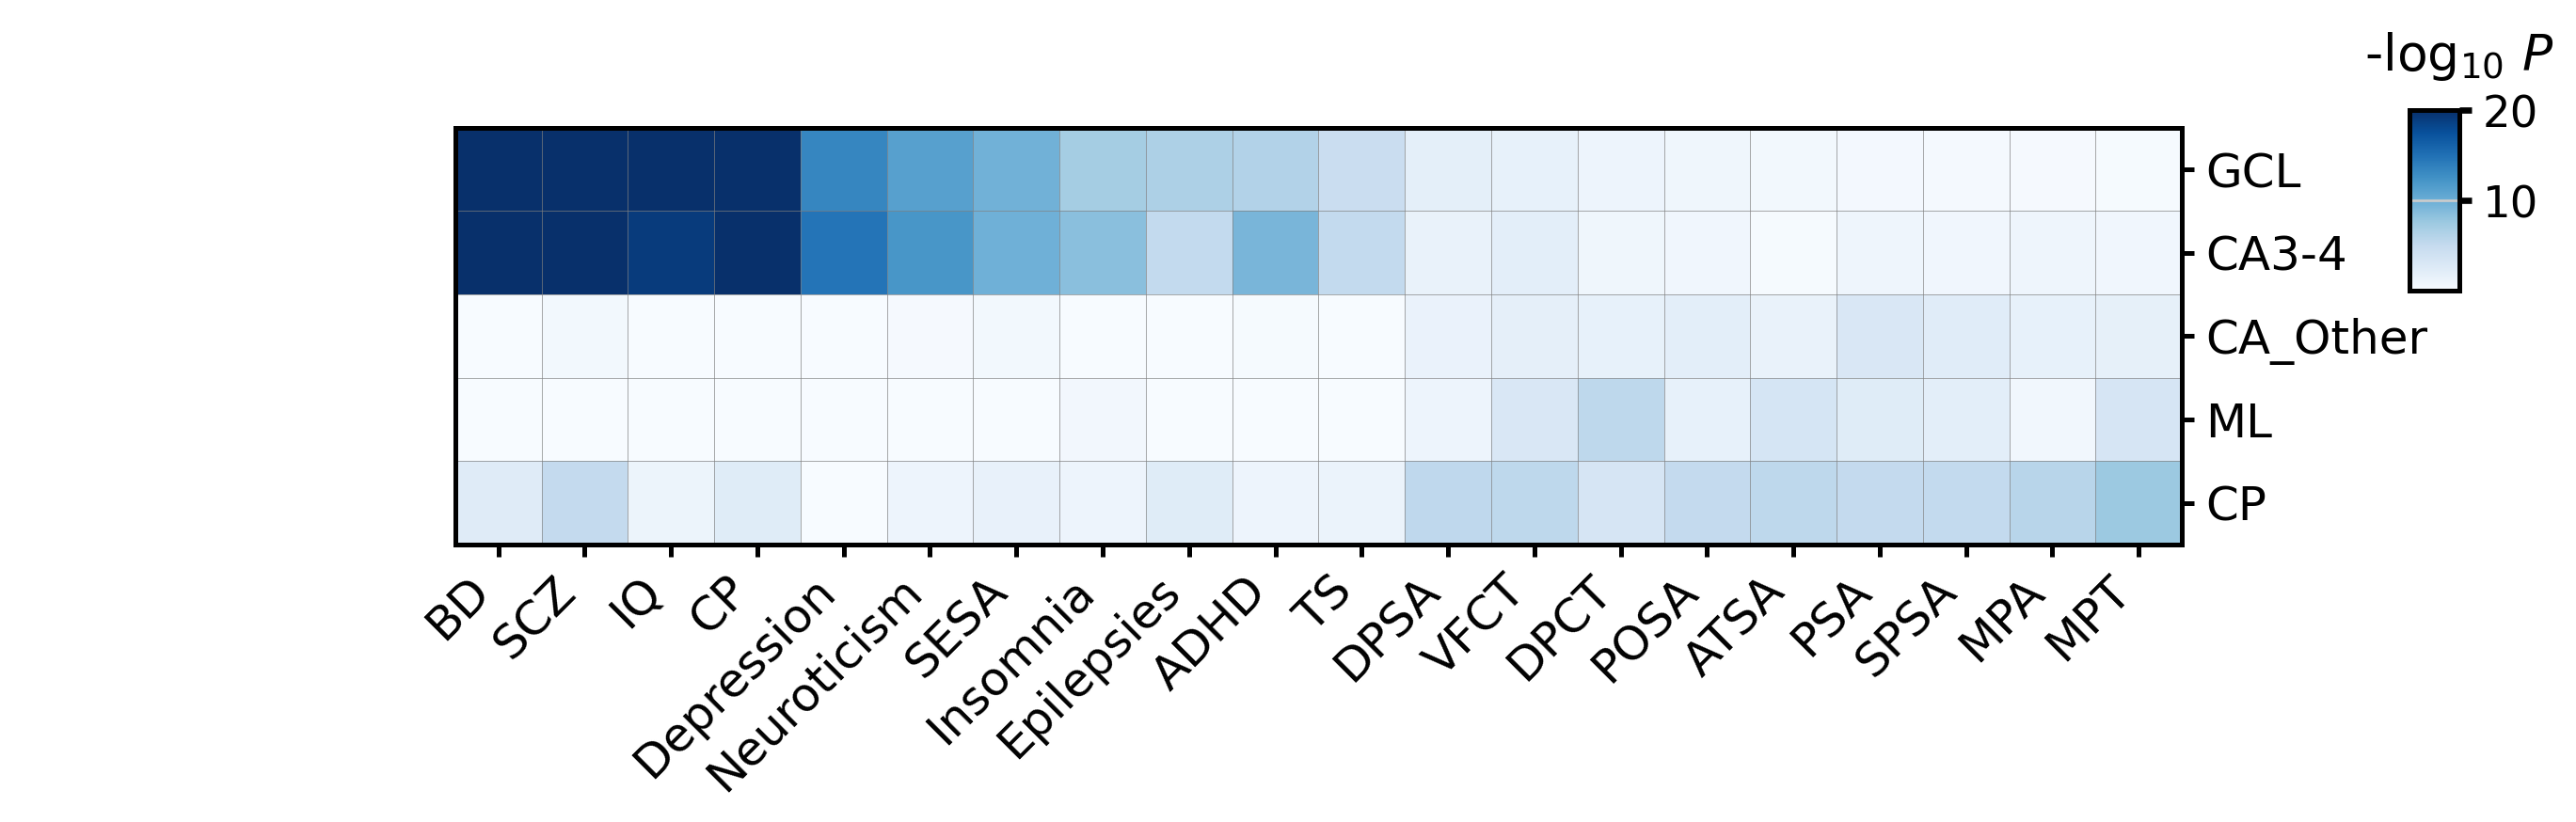

In [11]:
trait_name_map = {
    "parsopercularis_area_sumstat": "POSA",
    "superiorparietal_area_sumstat": "SPSA",
    "SESA_neuro_clus_sumstats": "SESA",
    "ILAE3_Caucasian_GGE_final": "Epilepsies",
    "PGC_Bipolar_INFO80_2021_NatGenet": "BPG_Bip",
    "bip2024_eur_no23andMe": "BD",
    "GIANT_EUR_Height_2022_Nature": "Height",
    "ADHD_2022_NatGenet": "ADHD",
    "Depression_2023_NatureMed": "Depression",
    "sumstats_neuroticism_ctg_format": "Neuroticism",
    "ADHD_adulthood_2022_NatGenet": "ADHD_AD",
    "precuneus_area_sumstat": "PSA",
    "dorsolateralprefrontal_thickness_sumstat": "DPCT",
    "motorpremotor_area_sumstat": "MPA",
    "PGC3_SCZ_wave3_public_INFO80": "SCZ",
    "Cognitive_Performance_2018_NatGenet": "CP",
    "medialprefrontal_thickness": "MPT",
    "dorsomedialfrontal_area_sumstat": "DPSA",
    "anteromedialtemporal_area_sumstat": "ATSA",
    "IQ_NG_2018": "IQ",
    "Insomnia_sumstats_Jansenetal": "Insomnia",
    "MDD_Howard_2019_NN": "MDD",
    "ventralfrontal_thickness_sumstat": "VFCT",
    "TS_Oct2018": "TS",
}
fig5_trait_order = [
    "POSA",
    "SPSA",
    "SESA",
    "Epilepsies",
    "BD",
    "ADHD",
    "Depression",
    "Neuroticism",
    "PSA",
    "DPCT",
    "MPA",
    "SCZ",
    "CP",
    "MPT",
    "DPSA",
    "ATSA",
    "IQ",
    "Insomnia",
    "VFCT",
    "TS",
]

cauchy_result = pd.read_csv(f"{DATA_DIR}/Cauchy_result.csv", index_col=0)
heatmap_df = cauchy_result.loc[DOMAIN_ORDER, list(trait_name_map)].rename(columns=trait_name_map)
heatmap_df = heatmap_df.loc[:, heatmap_df.gt(5).any(axis=0)]
heatmap_df = heatmap_df.loc[:, fig5_trait_order].sort_values("GCL", axis=1, ascending=False)

fig = ST.pl.create_gwas_heatmap(heatmap_df, figsize=(11, 4), vmax=20, cmap="Blues")
plt.show()


## GRN Enrichment in CA3-4 and GCL

STARNet can aggregate TF-level GRN scores across spatial domains. In this section, we use the merged `CA3-4 & GCL` label to identify GRNs enriched in the hippocampal region highlighted in Fig5.


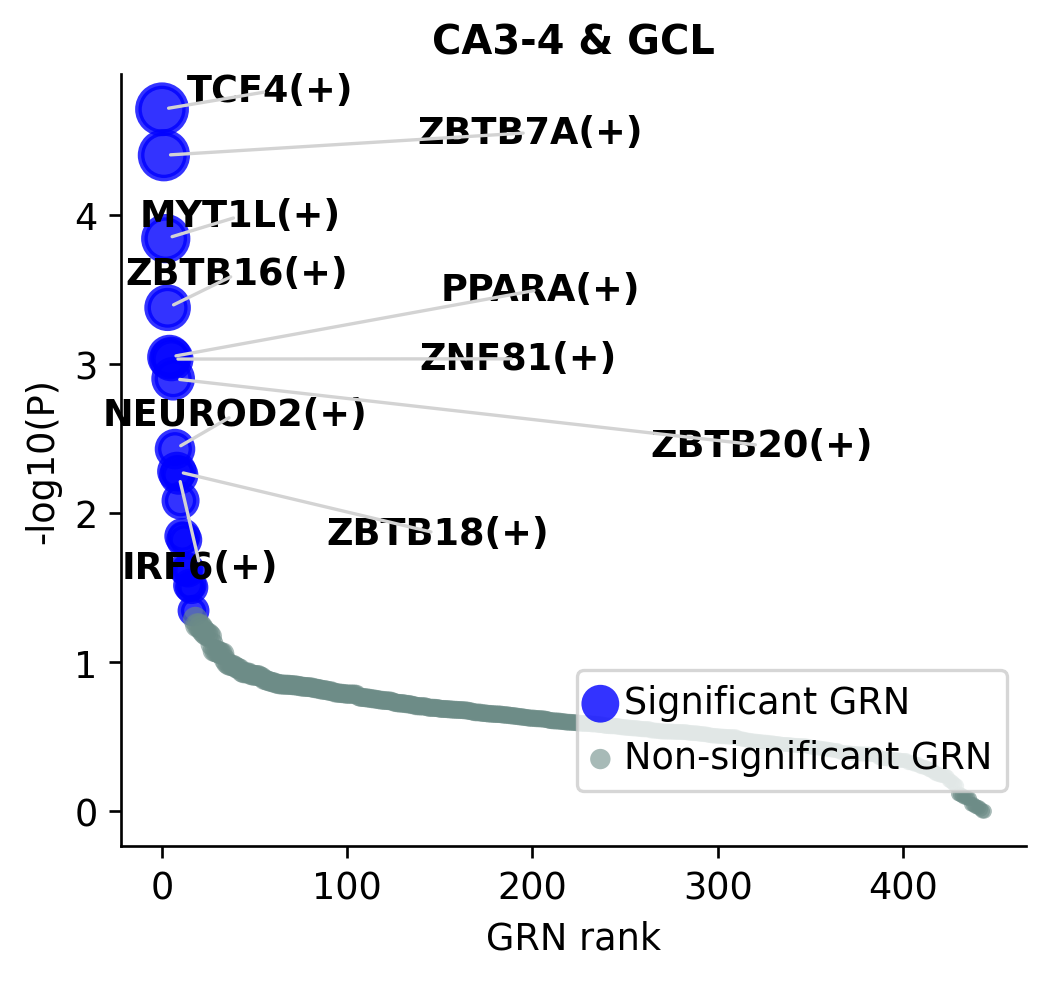

In [12]:
grn_domain_scores = ST.pp.cal_cauchy_combination_test(adata_rna, annotation_col="spatial domain new")
grn_domain_scores = grn_domain_scores.apply(pd.to_numeric, errors="coerce").fillna(0)
grn_domain_scores.index = grn_domain_scores.index + "(+)"

ax = ST.pl.plot_cauchy_combination_test(
    grn_domain_scores,
    n_top=10,
    spatial_domain="CA3-4 & GCL",
    color_non_significant="#6D8C87",
    bbox_to_anchor=(1, 0.15),
    fontsize=11,
    figsize=(4.5, 4),
)
ax.set_title("CA3-4 & GCL", fontsize=12, fontweight="bold")
ax.set_xlabel("GRN rank")
ax.set_ylabel("-log10(P)")
plt.show()


## Spatial Distribution of a GWAS Trait

Next, we inspect one trait at the spot level. The gsMap p-values are converted to `-log10(P)` and visualized over the spatial coordinates. The example uses schizophrenia (SCZ), which is also used for the SNP-level network analysis below.


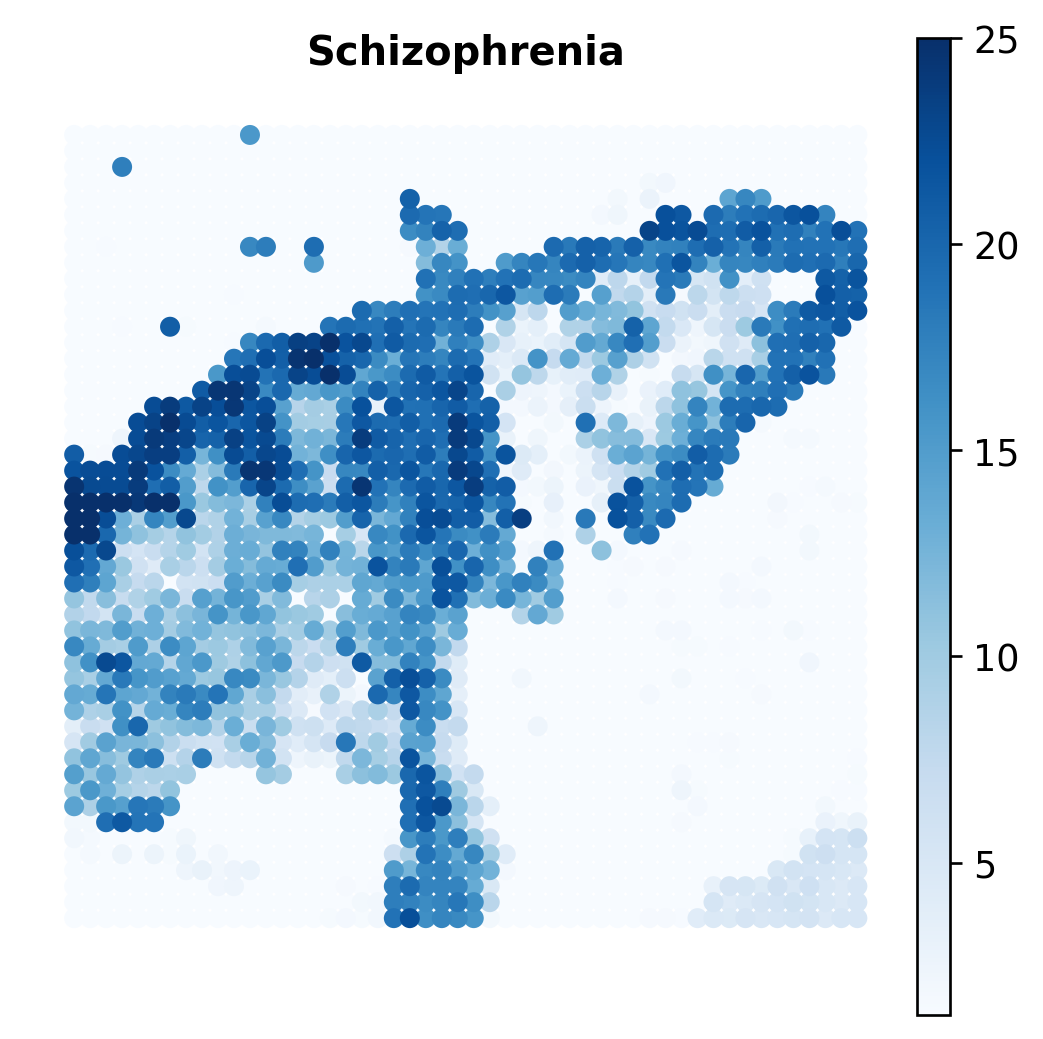

In [13]:
gsmap_pvalue = pd.read_csv(f"{DATA_DIR}/gsMap_pval.csv", index_col=0)
trait = "PGC3_SCZ_wave3_public_INFO80"
adata_rna.obs["SCZ -log10(P)"] = -np.log10(gsmap_pvalue.loc[adata_rna.obs_names, trait])

fig, ax = plt.subplots(figsize=(4.5, 4.5))
sc.pl.spatial(
    adata_rna,
    color="SCZ -log10(P)",
    cmap="Blues",
    spot_size=1.25,
    vmin=-np.log10(0.05),
    vmax=25,
    ax=ax,
    show=False,
    frameon=False,
)
ax.set_title("Schizophrenia", fontsize=12, fontweight="bold")
plt.show()


## GWAS-GRN Network

The schizophrenia GWAS summary statistics are used to find significant SNPs inside regulatory peaks linked to selected TF-target relationships. We focus on the Fig5 TFs `TCF4`, `MYT1L`, and `NEUROD2`.

STARNet first associates GWAS SNPs with TF-linked regulatory peaks, then filters SNPs by the `-log10(P) > 2` threshold used in Fig5. The network connects TFs to target genes with significant nearby SNPs. Target node colors represent the associated SNP p-values, and `NCAM1` is highlighted because it carries NEUROD2-linked schizophrenia SNPs in the downstream genome-track example.

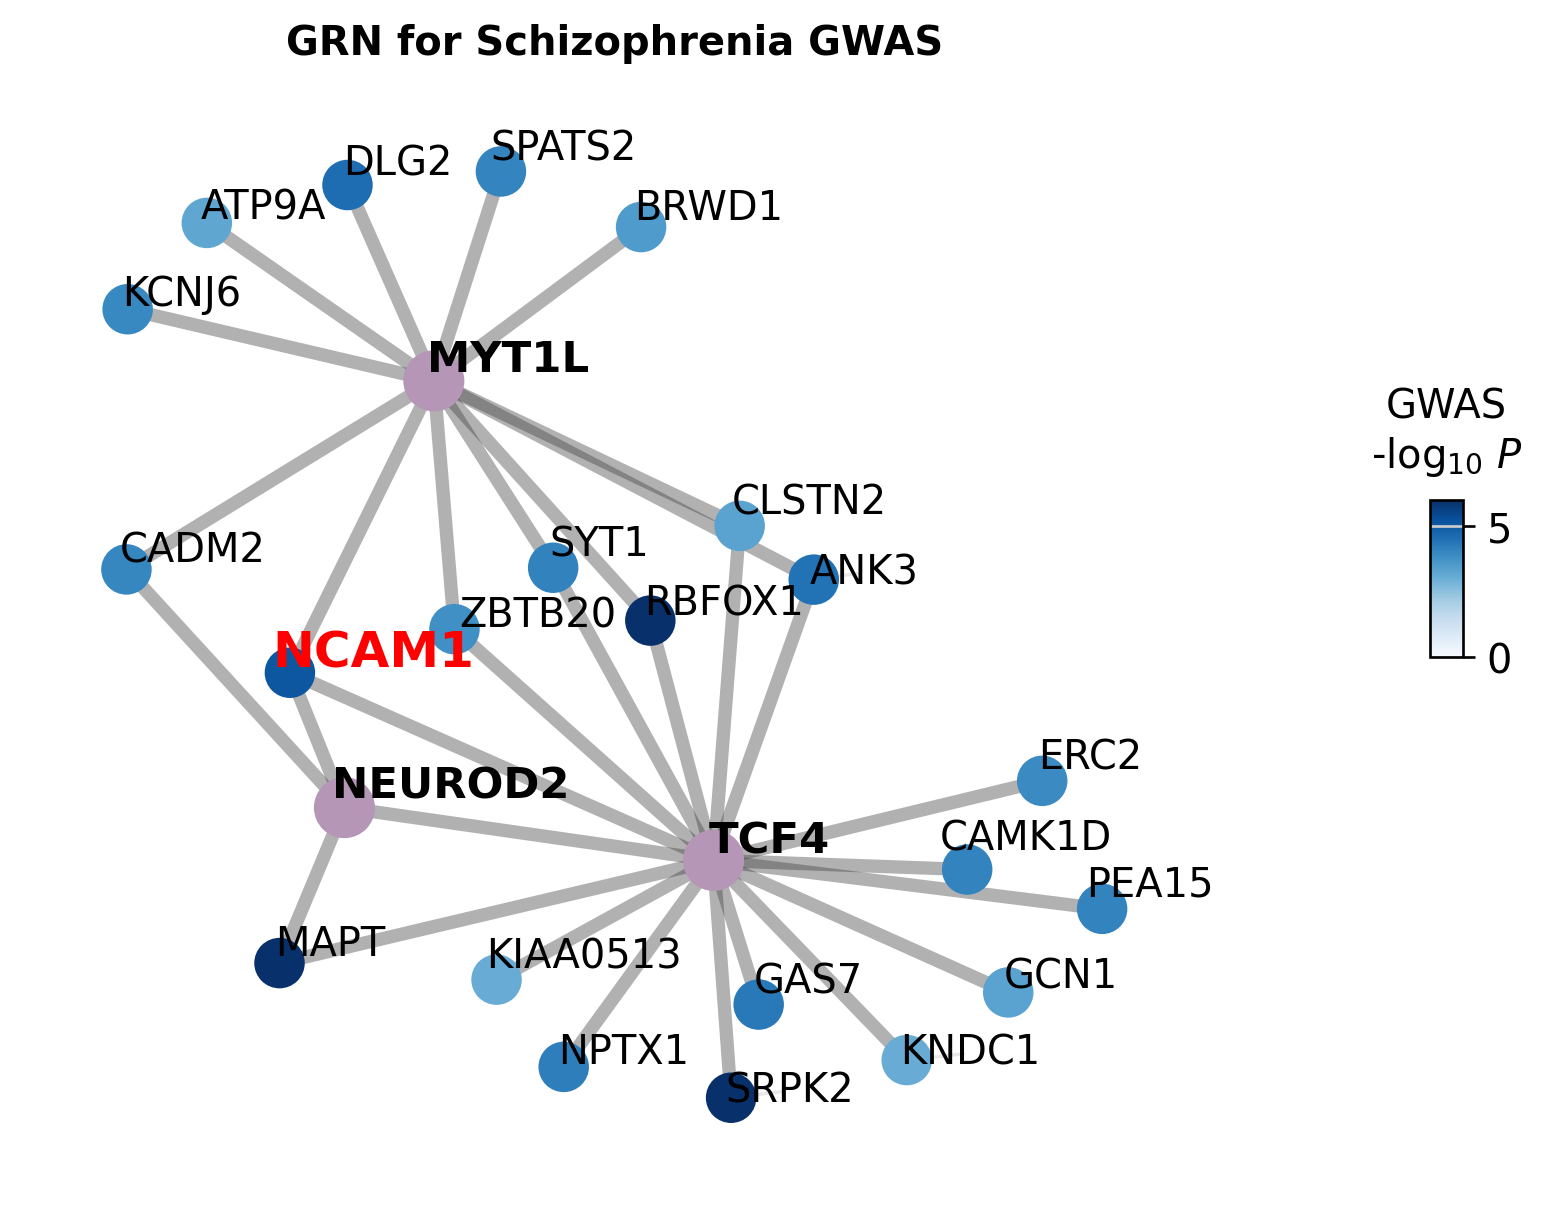

In [14]:
gwas_sumstats = pd.read_csv(SCZ_GWAS_PATH, sep="	")
tfs = ["TCF4", "MYT1L", "NEUROD2"]

target_gene_snp_dict = ST.pp.associate_snp_with_tf_regulatory_peaks(
    adata_rna=adata_rna,
    gwas_data=gwas_sumstats,
    gtf_path=GTF_PATH,
    tfs=tfs,
    verbose=False,
    show_progress=False,
)

significant_snps = ST.pp.identify_significant_snps(
    adata_rna=adata_rna,
    gwas_data=gwas_sumstats,
    gtf_path=GTF_PATH,
    significance_threshold=2,
    tfs=tfs,
    verbose=False,
    show_progress=False,
)

edge_color_dict = {tf: "#3e3e3e" for tf in tfs}

G, G_type_dict, G_color_dict = ST.pl.create_gwas_network(
    significant_snps=significant_snps,
    adata_rna=adata_rna,
    colormap="Blues",
    verbose=False,
)

fig, ax = ST.pl.gwas_grn_network(
    G,
    G_type_dict,
    G_color_dict,
    significant_snps,
    adata_rna=adata_rna,
    _G_edge_color_dict=edge_color_dict,
    specific_gene="NCAM1",
    figsize=(6.2, 5),
    edge_alpha=0.4,
    node_linewidths=1,
    node_alpha=1,
    show_colorbar=True,
    target_fontsize=12,
    TF_size=300,
    target_size=200,
    colormap="Blues",
    show_legend=False,
    colorbar_bbox=(1.03, 0.2, 0.35, 0.7),
    vmin=0,
    vmax=6,
    colorbar_size=0.08,
    label_log10pval_threshold=1.5,
)
ax.set_title("GRN for Schizophrenia GWAS", fontsize=12, fontweight="bold")
fig.subplots_adjust(right=0.82)
plt.show()


## NCAM1 Genome Track

The genome-track panel uses the same Fig5 AnnData object and ATAC track files copied into the tutorial data directory. We regenerate the peak-to-gene link table from `adata_rna.uns["Peak2Gene"]`, so the displayed NCAM1 link is derived from the same data snapshot used in the manuscript figure.

The highlighted interval marks the NEUROD2-associated regulatory region near `NCAM1`; the GWAS-GRN network above identifies schizophrenia SNPs in this peak.



🔗 Extracting Peak-Gene Associations for Visualization
 ⚙️ Loading GTF and aligning gene coordinates...
 ⚙️ Aggregating Peak-to-Gene links from .uns['Peak2Gene']...


 ⚙️ Parsing genomic coordinates...
 ⚙️ Calculating scores and formatting...
 📊 Association Extraction Summary:
   ✓ Total Raw Links      : 66,665
   ✓ Self-loops Removed   : 10
   ✓ Final Associations   : 66,655
 ✅ Formatting complete.
......Loading Peak2GeneLink
......Loading Peak
......Loading GCL
......Loading CA3-4
......Loading CA_Other
......Loading ML
......Loading CP
......Loading gtf file


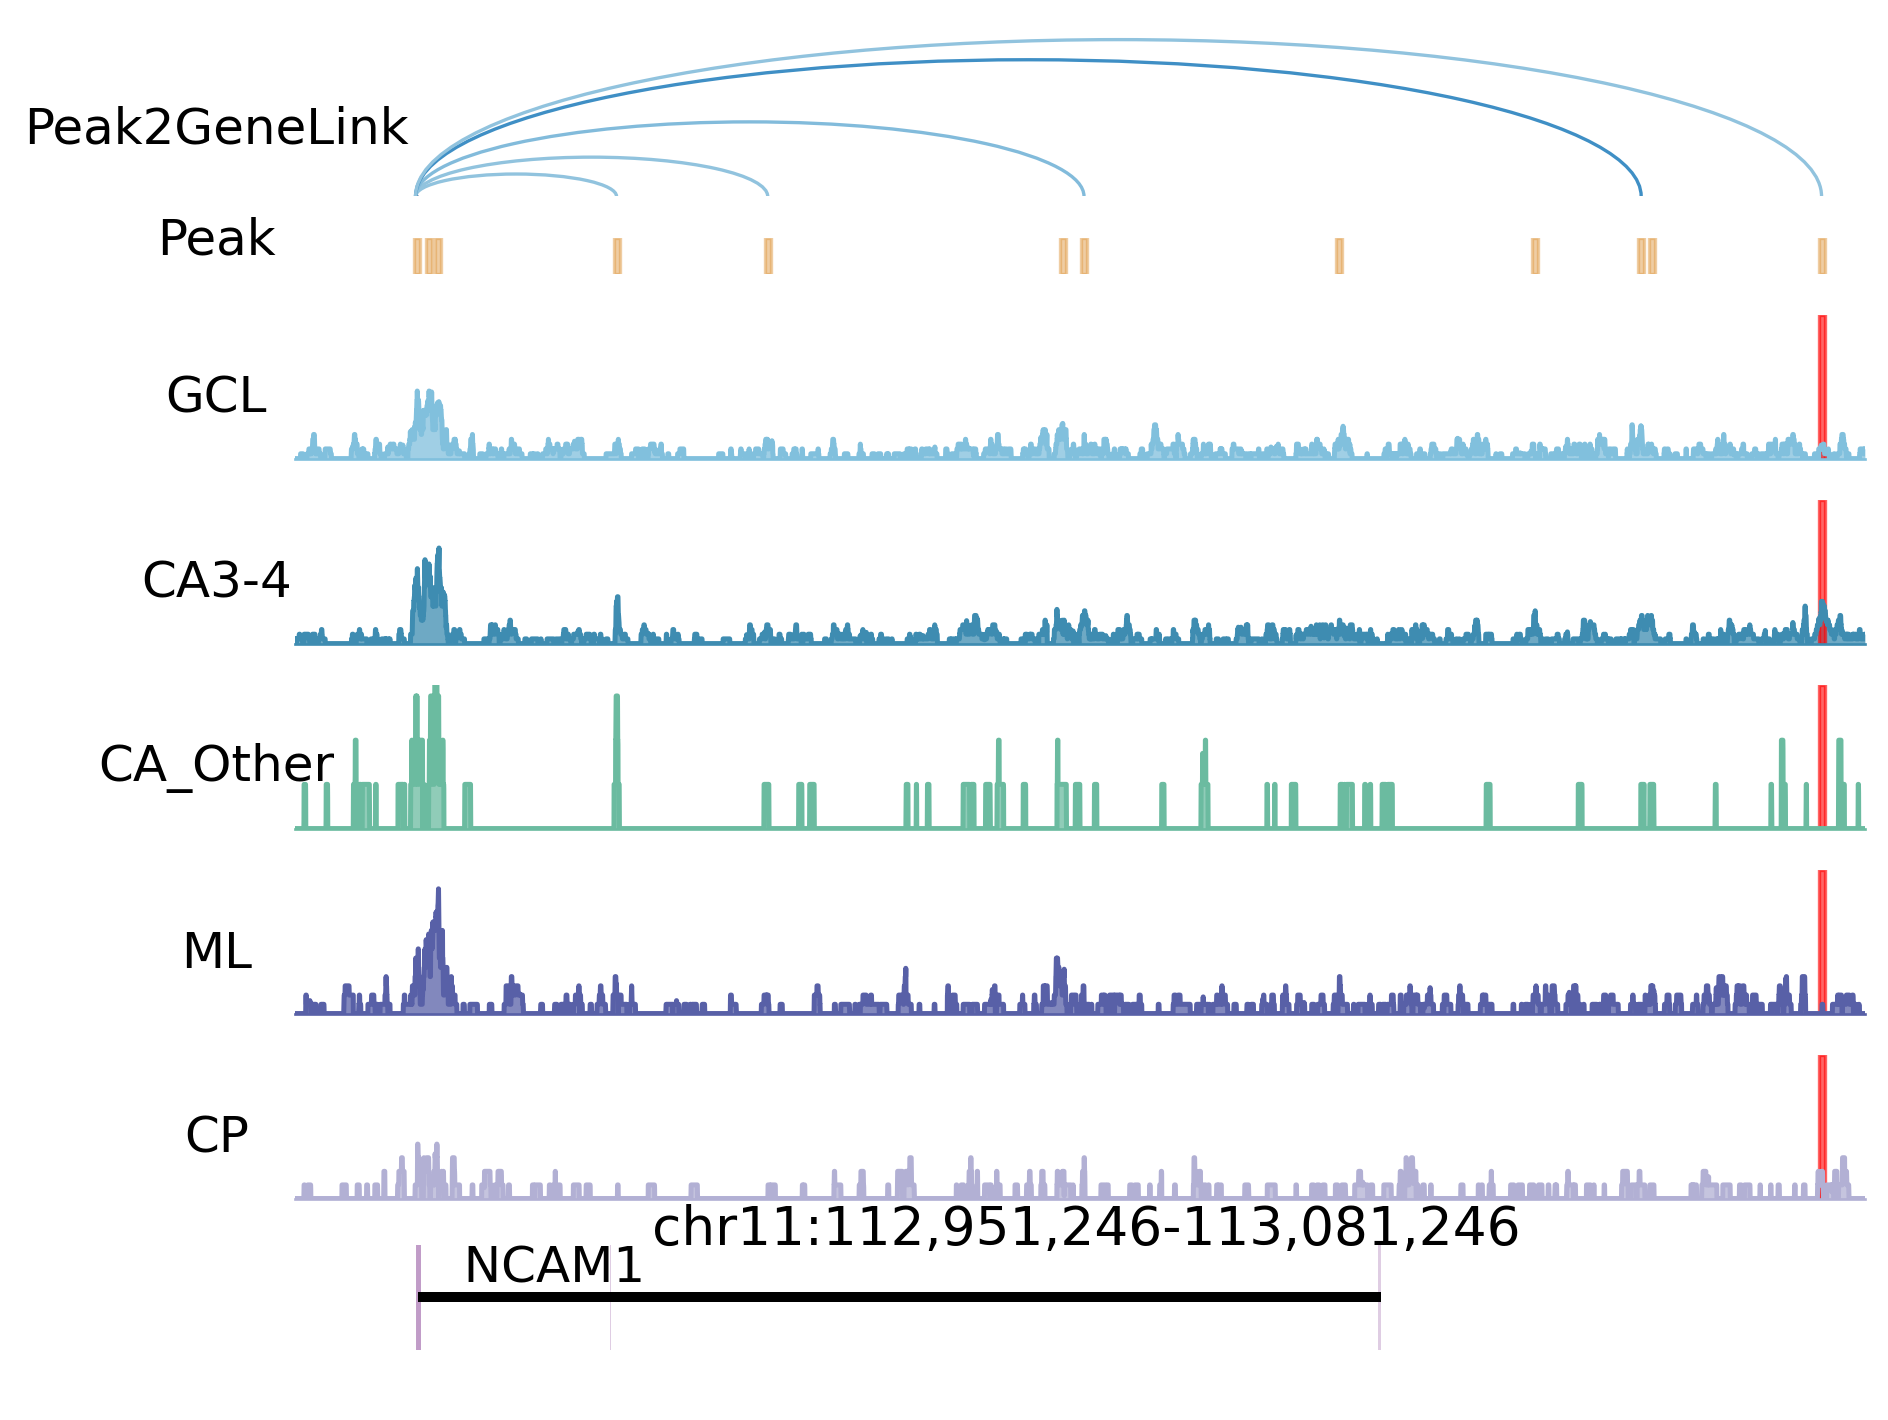

In [15]:
gtf_df = ST.pp.load_gtf(GTF_PATH, adata_rna.var_names)
peak2gene = ST.pp.extract_peak_gene_associations(adata_rna, gtf_file=GTF_PATH)
peak2gene_link_path = f"{DATA_DIR}/peak2gene.links"
peak2gene.to_csv(peak2gene_link_path, sep="	", index=False)

peak = [113077429, 113077930]
ncam1_peak_link = peak2gene[
    (peak2gene["chrom_y"] == "chr11")
    & (peak2gene["chromStart_y"] == peak[0])
    & (peak2gene["chromEnd_y"] == peak[1])
    & (peak2gene["chrom_x"] == "chr11")
    & (peak2gene["chromStart_x"] == 112961246)
]
if ncam1_peak_link.empty:
    raise ValueError("The Fig5 NCAM1 peak-to-gene link is missing from the extracted links.")

track_files = {
    "Peak2GeneLink": peak2gene_link_path,
    "Peak": f"{DATA_DIR}/ATAC/peaks.bed",
    "GCL": f"{DATA_DIR}/ATAC/GCL.bw",
    "CA3-4": f"{DATA_DIR}/ATAC/CA3_4.bw",
    "CA_Other": f"{DATA_DIR}/ATAC/Other.bw",
    "ML": f"{DATA_DIR}/ATAC/ML.bw",
    "CP": f"{DATA_DIR}/ATAC/CP.bw",
}
track = ST.external.epiverse.bigwig(track_files)
track.read()
track.load_gtf(GTF_PATH)

gene = "NCAM1"
loc = gtf_df.loc[gene]
chrom = loc["chrom"]
chrom_start = int(loc["chromStart"]) - 10000
chrom_end = int(loc["chromStart"]) + 120000
subplot_height_ratios = [1.2, 0.25, 1, 1, 1, 1, 1, 0.8, 0]

fig, ax = track.plot_track(
    chrom=chrom,
    chromstart=chrom_start,
    chromend=chrom_end,
    nbins=int((chrom_end - chrom_start) / 10),
    plot_names=["Peak2GeneLink", "Peak", "GCL", "CA3-4", "CA_Other", "ML", "CP"],
    figwidth=8,
    figheight=5,
    value_type="sum",
    subplot_height_ratios=subplot_height_ratios,
    color_dict={"Peak": "#E19D49", **DOMAIN_COLORS},
    region_dict={"region1": peak},
    region_color_dict={"region1": "#FF0000"},
    prefered_name="gene_name",
    ymax=20,
    text_height=1,
    text_length=0.5,
    plus_gtf_color="#C19CC8",
    minus_gtf_color="#9DB1DF",
    ylabel_coords=(-0.05, 0.25),
    text_fontsize=15,
    title_location=0.9,
    cmap=plt.cm.Blues,
    plot_arrow=False,
    vmax=2,
    spines=False,
    plot_ymax=False,
)

plt.suptitle(f"{chrom}:{chrom_start:,}-{chrom_end:,}", x=0.8, y=0.15, fontsize=16, ha="right")
plt.show()


## References

Please cite the relevant tools and resources when using this workflow:

- STARNet: Hu L, Zhang S, Zhang X, Luo Y, Gu H, Liu P, Mao S, Chen L, Xia Y, Yang M, Zhang S, Min Y, Li H, Wang P, Yu H, Zeng J. STARNet enables spatially resolved inference of gene regulatory networks from spatial multi-omics data. bioRxiv. 2025. doi: 10.1101/2025.08.21.671434.
- gsMap/spatial trait mapping: Song L, Chen W, Hou J, et al. Spatially resolved mapping of cells associated with human complex traits. Nature 641, 932-941 (2025). doi: 10.1038/s41586-025-08757-x.
- Scanpy: Wolf FA, Angerer P, Theis FJ. SCANPY: large-scale single-cell gene expression data analysis. Genome Biology 19, 15 (2018). doi: 10.1186/s13059-017-1382-0.
- NetworkX: Hagberg AA, Schult DA, Swart PJ. Exploring network structure, dynamics, and function using NetworkX. Proceedings of the 7th Python in Science Conference, 11-15 (2008).
- Logomaker: Tareen A, Kinney JB. Logomaker: beautiful sequence logos in Python. Bioinformatics 36, 2272-2274 (2020). doi: 10.1093/bioinformatics/btz921.